In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import warnings


In [7]:
df = pd.read_csv('processed_student_data.csv')
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

import joblib

model = joblib.load('../models/student_performance_model.pkl')

print("Model loaded successfully")
print("Features:", X.shape[1])

Model loaded successfully
Features: 34


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape[0])
print("Val:  ", X_val.shape[0])
print("Test: ", X_test.shape[0])

Train: 4624
Val:   991
Test:  992


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    model, X_train, y_train,
    cv=kf,
    scoring=['neg_mean_absolute_error',
             'neg_root_mean_squared_error',
             'r2'],
    return_train_score=True
)

print("--- 5-Fold Cross Validation Results ---")
print(f"MAE:  {-cv_results['test_neg_mean_absolute_error'].mean():.4f} "
      f"(+/- {cv_results['test_neg_mean_absolute_error'].std():.4f})")
print(f"RMSE: {-cv_results['test_neg_root_mean_squared_error'].mean():.4f} "
      f"(+/- {cv_results['test_neg_root_mean_squared_error'].std():.4f})")
print(f"R²:   {cv_results['test_r2'].mean():.4f} "
      f"(+/- {cv_results['test_r2'].std():.4f})")

--- 5-Fold Cross Validation Results ---
MAE:  0.7977 (+/- 0.0655)
RMSE: 2.2689 (+/- 0.4205)
R²:   0.6719 (+/- 0.0754)


In [10]:
test_preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
r2   = r2_score(y_test, test_preds)

print("--- Test Set Regression Metrics ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

--- Test Set Regression Metrics ---
MAE:  0.7116
RMSE: 1.9805
R²:   0.7386


In [11]:
def score_to_grade(score):
    if score >= 80:   return 'A'
    elif score >= 70: return 'B'
    elif score >= 60: return 'C'
    elif score >= 50: return 'D'
    else:             return 'F'

y_test_grades  = y_test.apply(score_to_grade)
y_pred_grades  = pd.Series(test_preds).apply(score_to_grade)

print("Grade distribution (actual):")
print(y_test_grades.value_counts().sort_index())

Grade distribution (actual):
Exam_Score
A      6
B    253
C    727
D      6
Name: count, dtype: int64


In [12]:
print("Classification Report (Grade Bands)")
print(classification_report(y_test_grades, y_pred_grades))

Classification Report (Grade Bands)
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
           B       0.95      0.81      0.88       253
           C       0.93      0.99      0.96       727
           D       1.00      0.67      0.80         6

    accuracy                           0.94       992
   macro avg       0.72      0.62      0.66       992
weighted avg       0.93      0.94      0.93       992



c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [13]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_grades)
y_pred_bin = lb.transform(y_pred_grades)

auc = roc_auc_score(y_test_bin, y_pred_bin,
                     multi_class='ovr', average='weighted')

print(f"Weighted AUC-ROC: {auc:.4f}")

Weighted AUC-ROC: 0.8932


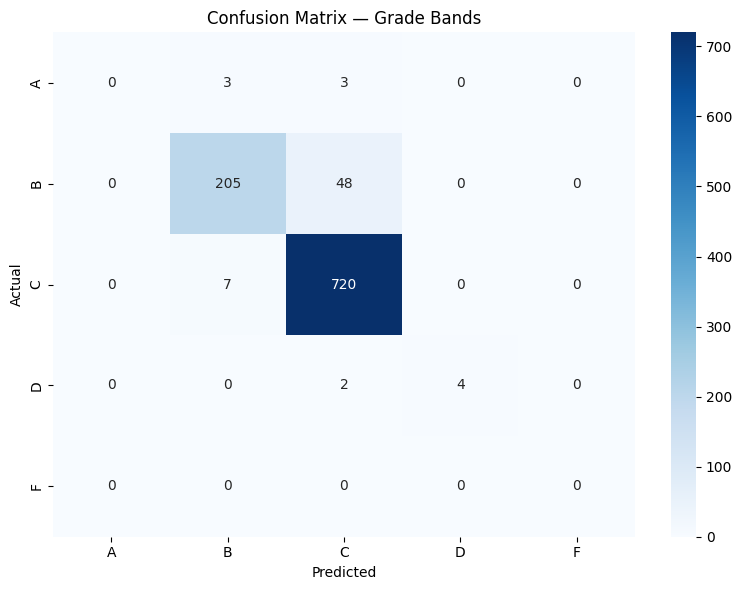

Saved: confusion_matrix.png


In [14]:
grades = ['A', 'B', 'C', 'D', 'F']
cm = confusion_matrix(y_test_grades, y_pred_grades, labels=grades)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grades, yticklabels=grades)
plt.title('Confusion Matrix — Grade Bands')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

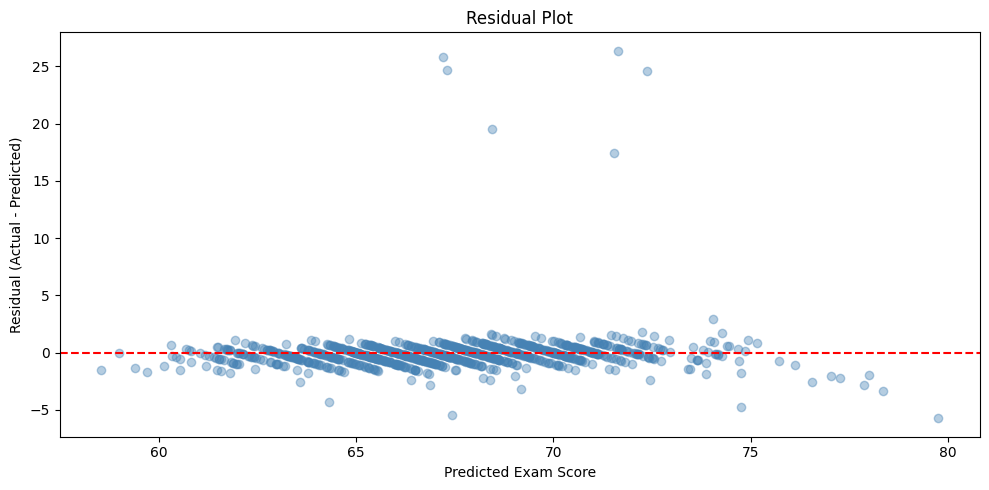

Saved: residual_plot.png


In [15]:
residuals = y_test.values - test_preds

plt.figure(figsize=(10, 5))
plt.scatter(test_preds, residuals, alpha=0.4, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()
print("Saved: residual_plot.png")

In [16]:
#Rebuild test set with original (unscaled) column names
X_test_df = X_test.copy()
X_test_df['Actual'] = y_test.values
X_test_df['Predicted'] = test_preds
X_test_df['Residual'] = X_test_df['Actual'] - X_test_df['Predicted']
X_test_df['AbsError'] = X_test_df['Residual'].abs()

bias_features = [
    'Access_to_Resources_Low',
    'Parental_Involvement_Low',
    'Learning_Disabilities_Yes'
]

print("--- Bias Check: Mean Absolute Error by Subgroup ---\n")
for col in bias_features:
    if col in X_test_df.columns:
        group = X_test_df.groupby(col)['AbsError'].mean()
        print(f"{col}:")
        print(group.to_string())
        print()

--- Bias Check: Mean Absolute Error by Subgroup ---

Access_to_Resources_Low:
Access_to_Resources_Low
False    0.719998
True     0.673590

Parental_Involvement_Low:
Parental_Involvement_Low
False    0.669834
True     0.877111

Learning_Disabilities_Yes:
Learning_Disabilities_Yes
False    0.703193
True     0.805186



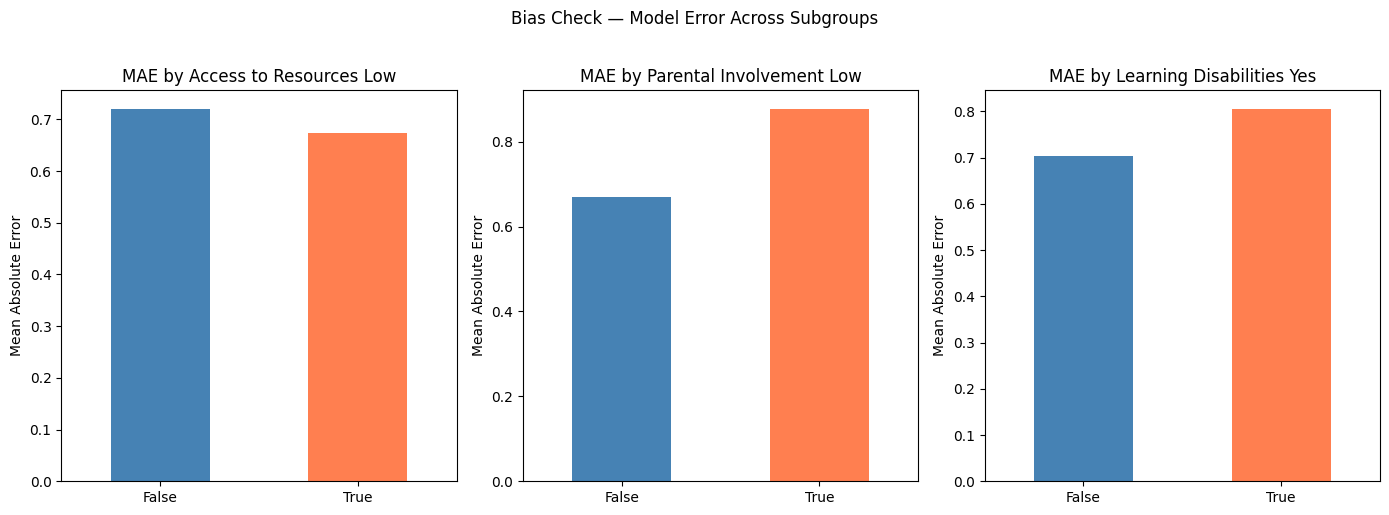

Saved: bias_check.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(bias_features):
    if col in X_test_df.columns:
        X_test_df.groupby(col)['AbsError'].mean().plot(
            kind='bar', ax=axes[i], color=['steelblue', 'coral']
        )
        axes[i].set_title(f'MAE by {col.replace("_", " ")}')
        axes[i].set_ylabel('Mean Absolute Error')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Bias Check — Model Error Across Subgroups', y=1.02)
plt.tight_layout()
plt.savefig('bias_check.png', dpi=150)
plt.show()
print("Saved: bias_check.png")